# Statistics in Python

### import package

In [1]:
import pandas as pd
from pandas import plotting
import numpy as np
from scipy import stats
import seaborn
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.formula.api import ols

### read data

In [2]:
data = pd.read_csv('brain_size.csv', sep=';', na_values=".")
data

,Unnamed: 0,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,1,Female,133,132,124,118.0,64.5,816932
1,2,Male,140,150,124,NaN,72.5,1001121
2,3,Male,139,123,150,143.0,73.3,1038437
3,4,Male,133,129,128,172.0,68.8,965353
4,5,Female,137,132,134,147.0,65.0,951545
5,6,Female,99,90,110,146.0,69.0,928799
6,7,Female,138,136,131,138.0,64.5,991305
7,8,Female,92,90,98,175.0,66.0,854258
8,9,Male,89,93,84,134.0,66.3,904858
9,10,Male,133,114,147,172.0,68.8,955466


### Creating from arrays

In [3]:
t = np.linspace(-6, 6, 20)
sin_t = np.sin(t)
cos_t = np.cos(t)
pd.DataFrame({'t': t, 'sin': sin_t, 'cos': cos_t})  

,t,sin,cos
0,-6.000000,0.279415,0.960170
1,-5.368421,0.792419,0.609977
2,-4.736842,0.999701,0.024451
3,-4.105263,0.821291,-0.570509
4,-3.473684,0.326021,-0.945363
5,-2.842105,-0.295030,-0.955488
6,-2.210526,-0.802257,-0.596979
7,-1.578947,-0.999967,-0.008151
8,-0.947368,-0.811882,0.583822
9,-0.315789,-0.310567,0.950551


In [4]:
data.shape # 40 rows and 8 columns

(40, 8)

In [5]:
data.columns # It has columns

Index(['Unnamed: 0', 'Gender', 'FSIQ', 'VIQ', 'PIQ', 'Weight', 'Height',
       'MRI_Count'],
      dtype='object')

In [6]:
print(data['Gender'])  # Columns can be addressed by name 

0     Female
1       Male
2       Male
3       Male
4     Female
5     Female
6     Female
7     Female
8       Male
9       Male
10    Female
11      Male
12      Male
13    Female
14    Female
15    Female
16    Female
17      Male
18    Female
19      Male
20      Male
21      Male
22    Female
23      Male
24    Female
25      Male
26    Female
27      Male
28    Female
29    Female
30    Female
31      Male
32      Male
33      Male
34    Female
35    Female
36      Male
37    Female
38      Male
39      Male
Name: Gender, dtype: object


In [7]:
data[data['Gender'] == 'Female']['VIQ'].mean()  # Simpler selector

np.float64(109.45)

### splitting a dataframe on values of categorical variables

In [8]:
groupby_gender = data.groupby('Gender')
for gender, value in groupby_gender['VIQ']:
    print((gender, value.mean()))

('Female', np.float64(109.45))
('Male', np.float64(115.25))


In [9]:
groupby_gender.mean()

,Unnamed: 0,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,,
Female,19.65,111.9,109.45,110.45,137.200000,65.765000,862654.6
Male,21.35,115.0,115.25,111.60,166.444444,71.431579,954855.4


## Scatter matrices

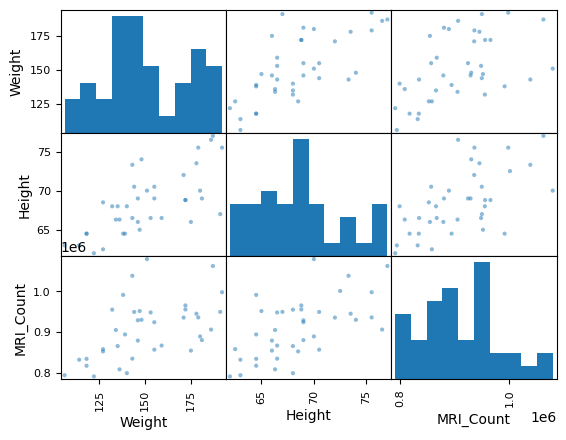

In [10]:
pd.plotting.scatter_matrix(data[['Weight', 'Height', 'MRI_Count']]);

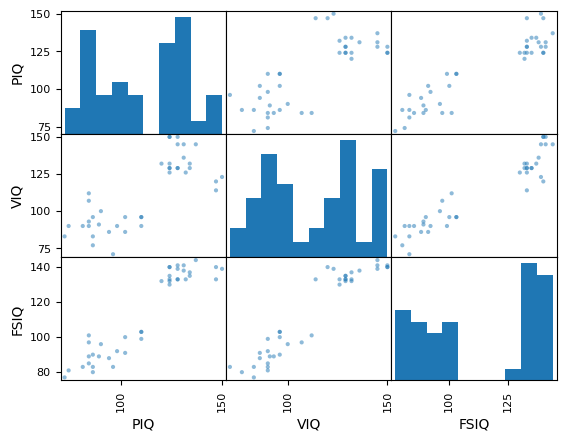

In [11]:
pd.plotting.scatter_matrix(data[['PIQ', 'VIQ', 'FSIQ']]);

## Hypothesis test 

### 1-sample t-test2-sample t-test

In [12]:
np.set_printoptions(legacy="1.25")
stats.ttest_1samp(data['VIQ'], 0)

TtestResult(statistic=30.08809997084933, pvalue=1.3289196468727879e-28, df=39)

### 2-sample t-test

In [13]:
female_viq = data[data['Gender'] == 'Female']['VIQ']
male_viq = data[data['Gender'] == 'Male']['VIQ']
stats.ttest_ind(female_viq, male_viq)

TtestResult(statistic=-0.7726161723275012, pvalue=0.44452876778583217, df=38.0)

### Pair test

#### independent samples

In [14]:
stats.ttest_ind(data['FSIQ'], data['PIQ'])

TtestResult(statistic=0.465637596380964, pvalue=0.6427725009414841, df=78.0)

#### paired measurements

In [15]:
stats.ttest_rel(data['FSIQ'], data['PIQ'])

TtestResult(statistic=1.7842019405859857, pvalue=0.08217263818364236, df=39)

#### One-Sample T-Test on Paired Differences

In [16]:
stats.ttest_1samp(data['FSIQ'] - data['PIQ'], 0)   

TtestResult(statistic=1.7842019405859857, pvalue=0.08217263818364236, df=39)

#### Wilcoxon Signed-Rank Test

In [17]:
stats.wilcoxon(data['FSIQ'], data['PIQ'])

WilcoxonResult(statistic=274.5, pvalue=0.10659492713506856)

## 3.1.3. Linear models, multiple factors, and analysis of variance

#### A simple linear regression

In [18]:
x = np.linspace(-5, 5, 20)
np.random.seed(1)
# normal distributed noise
y = -5 + 3*x + 4 * np.random.normal(size=x.shape)
# Create a data frame containing all the relevant variables
data = pd.DataFrame({'x': x, 'y': y})

#### OLS model and fit

In [19]:
model = ols("y ~ x", data).fit()
print(model.summary()) 

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     74.03
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           8.56e-08
Time:                        14:30:28   Log-Likelihood:                -57.988
No. Observations:                  20   AIC:                             120.0
Df Residuals:                      18   BIC:                             122.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.5335      1.036     -5.342      0.0

## comparing groups or multiple categories

#### using a linear model

In [20]:
data = pd.read_csv("brain_size.csv", sep=";", na_values=".")
model = ols("VIQ ~ Gender + 1", data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Mon, 27 Jul 2026   Prob (F-statistic):              0.445
Time:                        14:30:28   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        109.4500      5.308     20.

#### Forcing categorical

In [21]:
model = ols('VIQ ~ C(Gender)', data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Mon, 27 Jul 2026   Prob (F-statistic):              0.445
Time:                        14:30:28   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           109.4500      5.30

#### Link to t-tests between different 

In [22]:
data_fisq = pd.DataFrame({'iq': data['FSIQ'], 'type': 'fsiq'})
data_piq = pd.DataFrame({'iq': data['PIQ'], 'type': 'piq'})
data_long = pd.concat((data_fisq, data_piq))
print(data_long)  

     iq  type
0   133  fsiq
1   140  fsiq
2   139  fsiq
3   133  fsiq
4   137  fsiq
..  ...   ...
35  128   piq
36  124   piq
37   94   piq
38   74   piq
39   89   piq

[80 rows x 2 columns]


In [23]:
model = ols("iq ~ type", data_long).fit()
print(model.summary())  

                            OLS Regression Results                            
Dep. Variable:                     iq   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.2168
Date:                Mon, 27 Jul 2026   Prob (F-statistic):              0.643
Time:                        14:30:29   Log-Likelihood:                -364.35
No. Observations:                  80   AIC:                             732.7
Df Residuals:                      78   BIC:                             737.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     113.4500      3.683     30.807      

## Multiple Regression: including multiple factors

In [24]:
data = pd.read_csv('iris.csv')
model = ols('sepal_width ~ name + petal_length', data).fit()
print(model.summary()) 

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        14:30:29   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.9813      0

## Post-hoc hypothesis testing: analysis of variance (ANOVA)

In [25]:
print(model.f_test([0, 1, -1, 0]))  

<F test: F=3.2453353465743553, p=0.07369058781700252, df_denom=146, df_num=1>


## More visualization: seaborn for statistical exploration

In [26]:
print(data) 

     sepal_length  sepal_width  petal_length  petal_width       name
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


## loading table

In [27]:
names = [
    'EDUCATION: Number of years of education',
    'SOUTH: 1=Person lives in South, 0=Person lives elsewhere',
    'SEX: 1=Female, 0=Male',
    'EXPERIENCE: Number of years of work experience',
    'UNION: 1=Union member, 0=Not union member',
    'WAGE: Wage (dollars per hour)',
    'AGE: years',
    'RACE: 1=Other, 2=Hispanic, 3=White',
    'OCCUPATION: 1=Management, 2=Sales, 3=Clerical, 4=Service, 5=Professional, 6=Other',
    'SECTOR: 0=Other, 1=Manufacturing, 2=Construction',
    'MARR: 0=Unmarried,  1=Married',
]

short_names = [n.split(':')[0] for n in names]
data = pd.read_csv('wages.txt', skiprows=27, skipfooter=6, sep=None,
                       header=None,engine="python")
data.columns = short_names

# Log-transform the wages, because they typically are increased with
# multiplicative factors
data['WAGE'] = np.log10(data['WAGE'])

In [28]:
print(data)

     EDUCATION  SOUTH  SEX  EXPERIENCE  UNION      WAGE  AGE  RACE  \
0            8      0    1          21      0  0.707570   35     2   
1            9      0    1          42      0  0.694605   57     3   
2           12      0    0           1      0  0.824126   19     3   
3           12      0    0           4      0  0.602060   22     3   
4           12      0    0          17      0  0.875061   35     3   
..         ...    ...  ...         ...    ...       ...  ...   ...   
529         18      0    0           5      0  1.055378   29     3   
530         12      0    1          33      0  0.785330   51     1   
531         17      0    1          25      1  1.366423   48     1   
532         12      1    0          13      1  1.298416   31     3   
533         16      0    0          33      0  1.186956   55     3   

     OCCUPATION  SECTOR  MARR  
0             6       1     1  
1             6       1     1  
2             6       1     0  
3             6       0     0  

#### Pairplot: scatter matrices

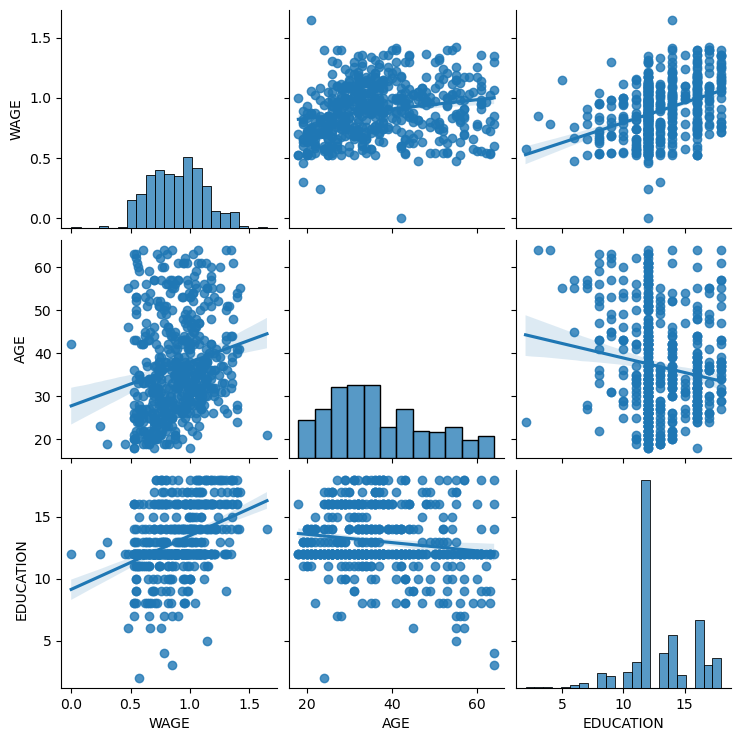

In [29]:
seaborn.pairplot(data, vars=['WAGE', 'AGE', 'EDUCATION'],
                 kind='reg');

#### Categorical variables

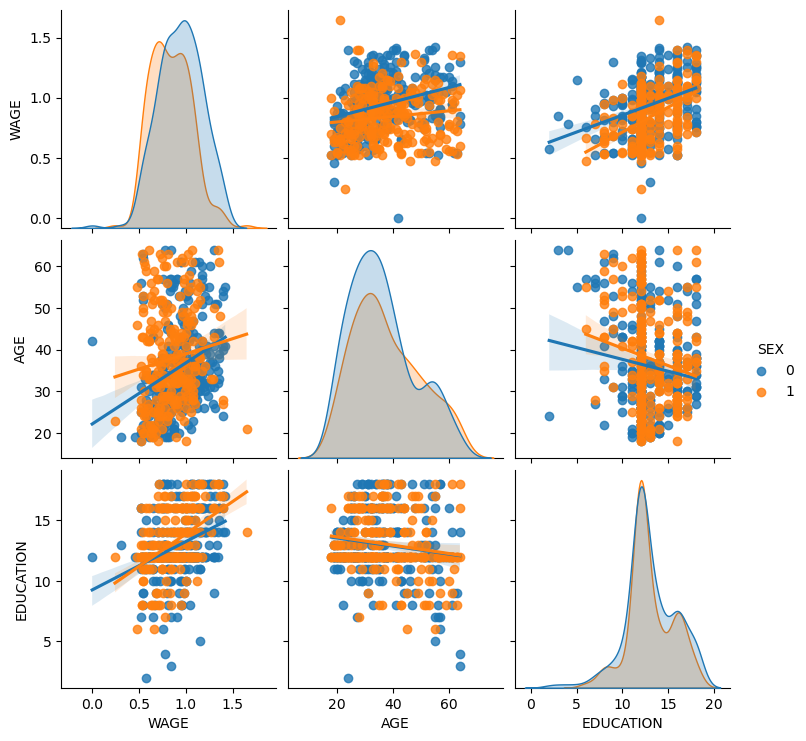

In [30]:
seaborn.pairplot(data, vars=['WAGE', 'AGE', 'EDUCATION'],
                 kind='reg', hue='SEX');

#### switch set

In [31]:
from matplotlib import pyplot as plt
plt.rcdefaults()

### plotting a univariate regression

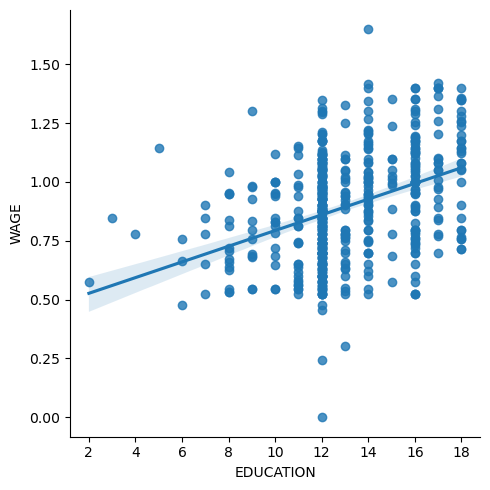

In [32]:
seaborn.lmplot(y='WAGE', x='EDUCATION', data=data)  

### Testing for interactions

In [33]:
data = data.rename(
    columns={
        "WAGE": "wage",
        "EDUCATION": "education",
        "SEX": "gender"})

data["gender"] = data["gender"].replace({0: "male", 1: "female"})
result = sm.ols(formula='wage ~ education + gender + education * gender',
                data=data).fit()  
print(result.summary()) 

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     43.72
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           2.94e-25
Time:                        14:30:33   Log-Likelihood:                 88.503
No. Observations:                 534   AIC:                            -169.0
Df Residuals:                     530   BIC:                            -151.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

## For each figure

### Boxplots and paired differences

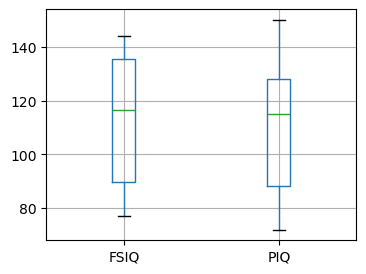

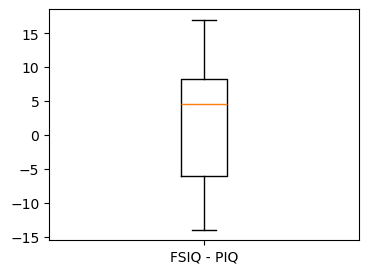

In [34]:
data = pd.read_csv('brain_size.csv', sep=';', na_values='.')

# Box plot of FSIQ and PIQ (different measures od IQ)
plt.figure(figsize=(4, 3))
data.boxplot(column=['FSIQ', 'PIQ'])

# Boxplot of the difference
plt.figure(figsize=(4, 3))
plt.boxplot(data['FSIQ'] - data['PIQ'])
plt.xticks((1, ), ('FSIQ - PIQ', ))

plt.show()

### Plotting simple quantities of a pandas dataframe

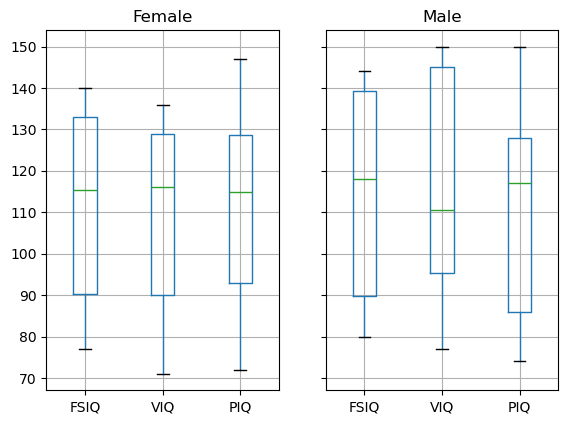

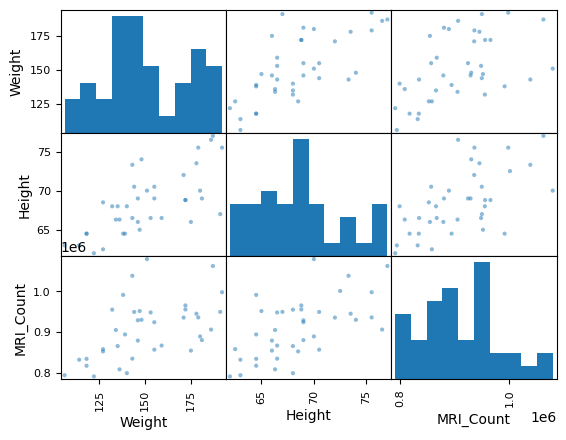

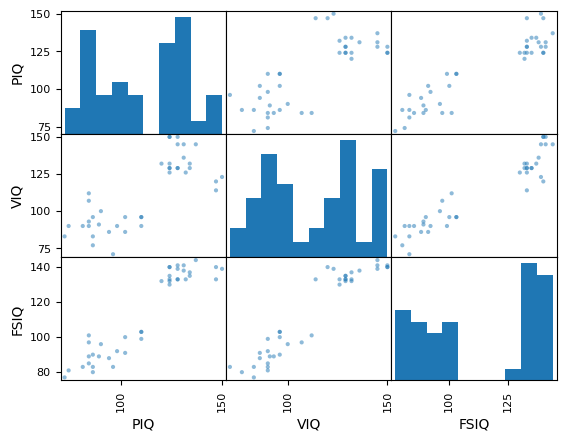

In [35]:
data = pd.read_csv('brain_size.csv', sep=';', na_values='.')
# Box plots of different columns for each gender
groupby_gender = data.groupby('Gender')
groupby_gender.boxplot(column=['FSIQ', 'VIQ', 'PIQ'])
# Scatter matrices for different columns
plotting.scatter_matrix(data[['Weight', 'Height', 'MRI_Count']])
plotting.scatter_matrix(data[['PIQ', 'VIQ', 'FSIQ']])
plt.show()

### Analysis of Iris petal and sepal sizes

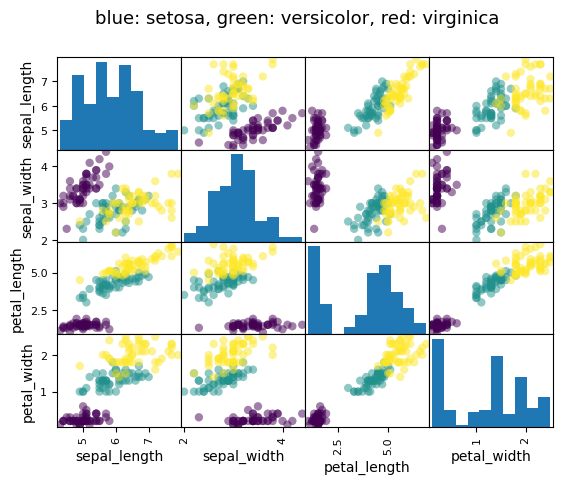

In [36]:
data = pd.read_csv('iris.csv')
categories = pd.Categorical(data['name'])

# The parameter 'c' is passed to plt.scatter and will control the color
plotting.scatter_matrix(data, c=categories.codes, marker='o')

fig = plt.gcf()
fig.suptitle("blue: setosa, green: versicolor, red: virginica", size=13);

In [37]:
model = ols('sepal_width ~ name + petal_length', data).fit()
print(model.summary())
print('Testing the difference between effect of versicolor and virginica')
print(model.f_test([0, 1, -1, 0]))
plt.show()

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        14:30:34   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.9813      0

### Simple Regression

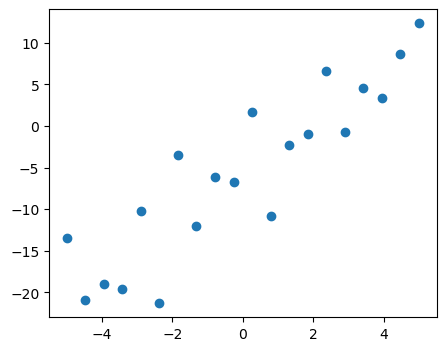

In [38]:
x = np.linspace(-5, 5, 20)
# To get reproducable values, provide a seed value
np.random.seed(1)
y = -5 + 3*x + 4 * np.random.normal(size=x.shape)
# Plot the data
plt.figure(figsize=(5, 4))
plt.plot(x, y, 'o');

In [39]:
data = pd.DataFrame({'x': x, 'y': y})

# Fit the model
model = ols("y ~ x", data).fit()

# Print the summary
print(model.summary())

# Peform analysis of variance on fitted linear model
anova_results = anova_lm(model)

print('\nANOVA results')
print(anova_results)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     74.03
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           8.56e-08
Time:                        14:30:34   Log-Likelihood:                -57.988
No. Observations:                  20   AIC:                             120.0
Df Residuals:                      18   BIC:                             122.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.5335      1.036     -5.342      0.0

#### Retrieve the parameter estimates

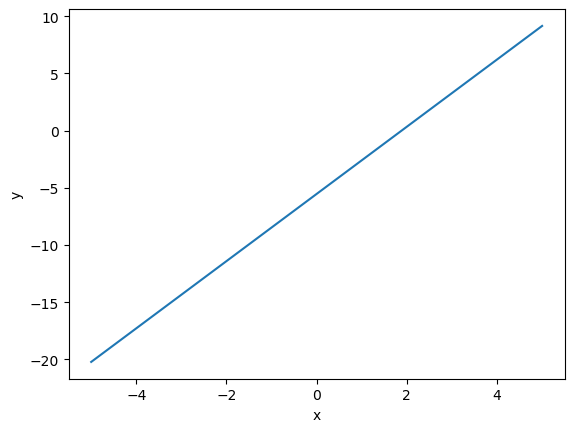

In [40]:
offset, coef = model._results.params
plt.plot(x, x*coef + offset)
plt.xlabel('x')
plt.ylabel('y')

plt.show()

### Multiple Regression 3D

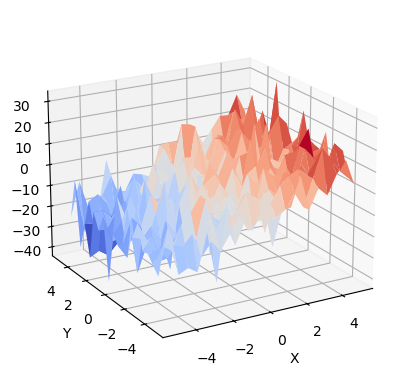

In [41]:
x = np.linspace(-5, 5, 21)
# We generate a 2D grid
X, Y = np.meshgrid(x, x)

# To get reproducable values, provide a seed value
np.random.seed(1)

# Z is the elevation of this 2D grid
Z = -5 + 3*X - 0.5*Y + 8 * np.random.normal(size=X.shape)

# Plot the data
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
surf = ax.plot_surface(X, Y, Z, cmap=plt.cm.coolwarm,
                       rstride=1, cstride=1)
ax.view_init(20, -120);
ax.set_xlabel('X');
ax.set_ylabel('Y');
ax.set_zlabel('Z');

### Test for an education/gender interaction in wages

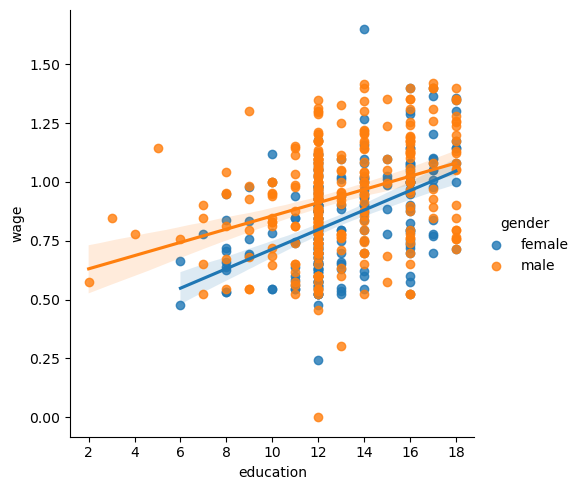

In [42]:
data = pd.read_csv('wages.txt', skiprows=27, skipfooter=6, sep=None,
                       header=None, names=['education', 'gender', 'wage'],
                       usecols=[0, 2, 5],engine="python")
data['gender'] = np.choose(data.gender, ['male', 'female'])

# Log-transform the wages, because they typically are increased with
# multiplicative factors
data['wage'] = np.log10(data['wage'])
seaborn.lmplot(y='wage', x='education', hue='gender', data=data);

### statistical analysis

In [43]:
result = sm.ols(formula='wage ~ education + gender', data=data).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     63.42
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           2.01e-25
Time:                        14:30:35   Log-Likelihood:                 86.654
No. Observations:                 534   AIC:                            -167.3
Df Residuals:                     531   BIC:                            -154.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4053      0.046      8.

###  model this using an interaction

In [44]:
result = sm.ols(formula='wage ~ education + gender + education * gender',
                data=data).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     43.72
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           2.94e-25
Time:                        14:30:35   Log-Likelihood:                 88.503
No. Observations:                 534   AIC:                            -169.0
Df Residuals:                     530   BIC:                            -151.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Visualizing factors influencing wages

In [45]:
# Give names to the columns
names = [
    'EDUCATION: Number of years of education',
    'SOUTH: 1=Person lives in South, 0=Person lives elsewhere',
    'SEX: 1=Female, 0=Male',
    'EXPERIENCE: Number of years of work experience',
    'UNION: 1=Union member, 0=Not union member',
    'WAGE: Wage (dollars per hour)',
    'AGE: years',
    'RACE: 1=Other, 2=Hispanic, 3=White',
    'OCCUPATION: 1=Management, 2=Sales, 3=Clerical, 4=Service, 5=Professional, 6=Other',
    'SECTOR: 0=Other, 1=Manufacturing, 2=Construction',
    'MARR: 0=Unmarried,  1=Married',
]

short_names = [n.split(':')[0] for n in names]

data = pd.read_csv('wages.txt', skiprows=27, skipfooter=6, sep=None,
                       header=None,engine="python")
data.columns = short_names

# Log-transform the wages, because they typically are increased with
# multiplicative factors
data['WAGE'] = np.log10(data['WAGE'])

### Plot scatter matrices highlighting different aspects

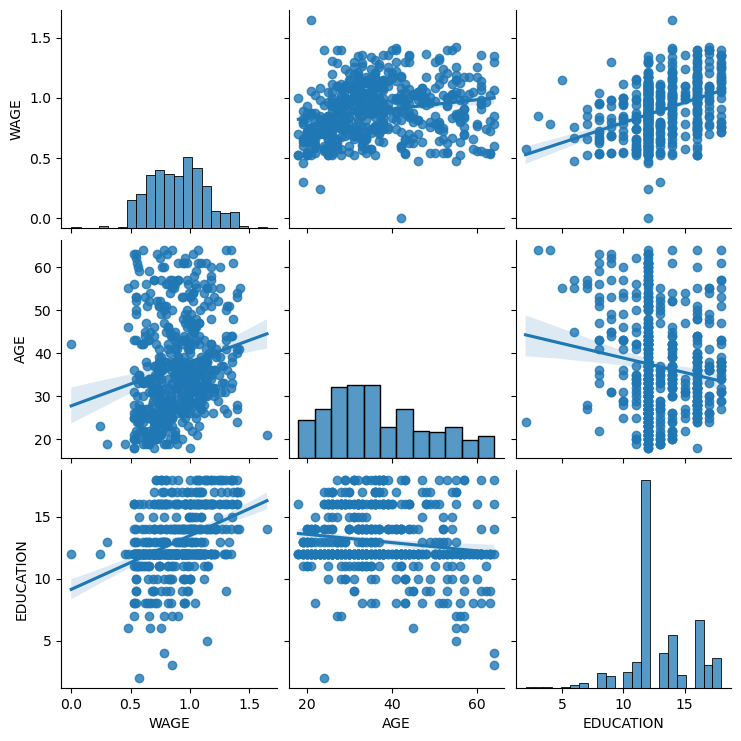

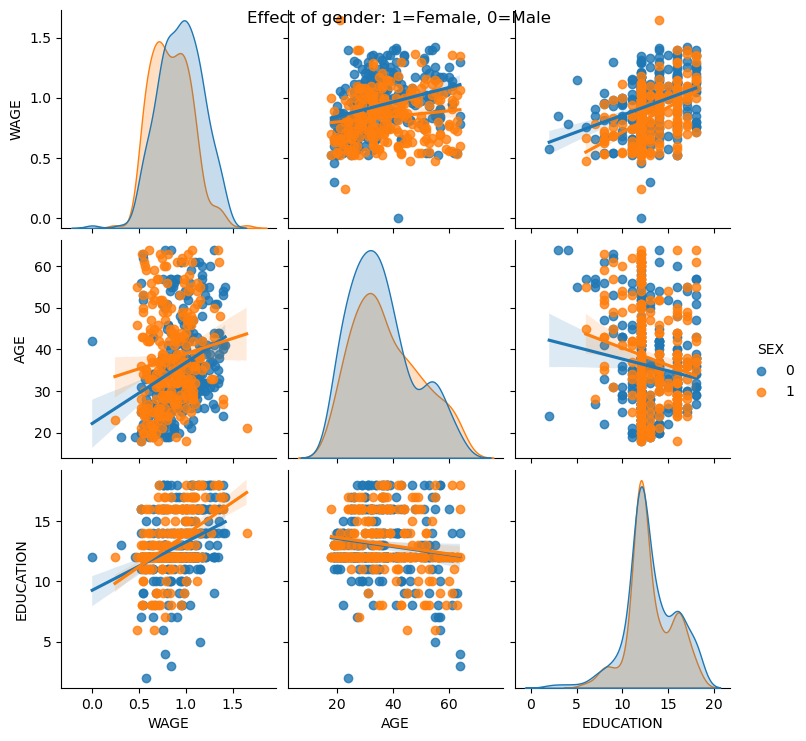

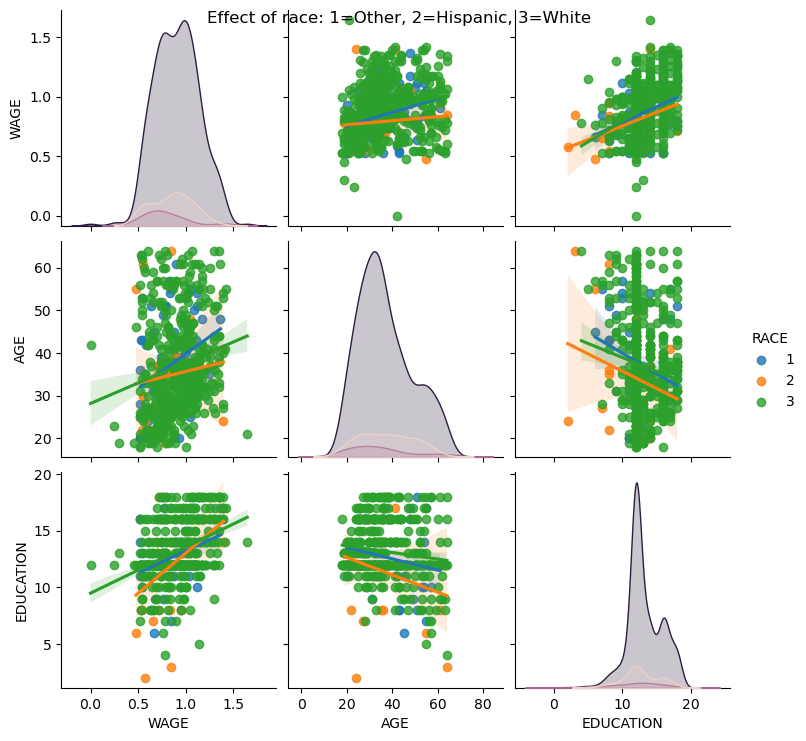

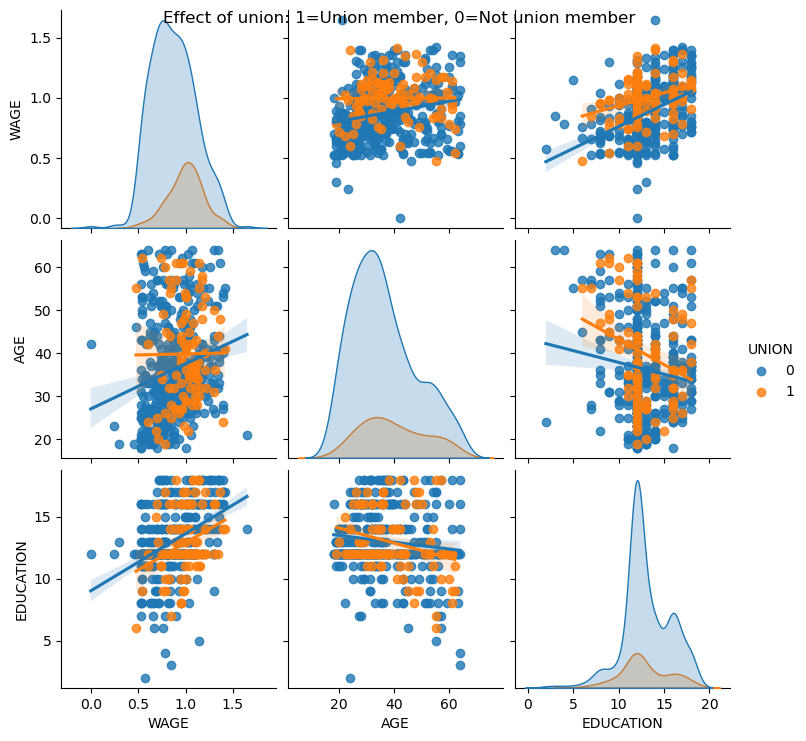

In [46]:
seaborn.pairplot(data, vars=['WAGE', 'AGE', 'EDUCATION'],
                      kind='reg')

seaborn.pairplot(data, vars=['WAGE', 'AGE', 'EDUCATION'],
                      kind='reg', hue='SEX')
plt.suptitle('Effect of gender: 1=Female, 0=Male')

seaborn.pairplot(data, vars=['WAGE', 'AGE', 'EDUCATION'],
                      kind='reg', hue='RACE')
plt.suptitle('Effect of race: 1=Other, 2=Hispanic, 3=White')

seaborn.pairplot(data, vars=['WAGE', 'AGE', 'EDUCATION'],
                      kind='reg', hue='UNION')
plt.suptitle('Effect of union: 1=Union member, 0=Not union member');

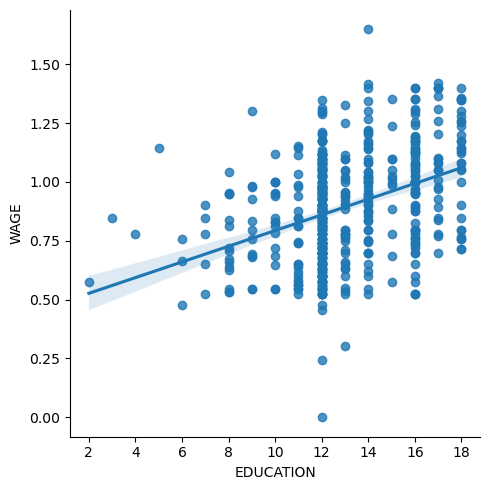

In [47]:
seaborn.lmplot(y='WAGE', x='EDUCATION', data=data)

plt.show()

### Air fares before and after 9/11

In [48]:
data = pd.read_csv('airfares.txt', sep=' +', header=0,
                       names=['city1', 'city2', 'pop1', 'pop2',
                              'dist', 'fare_2000', 'nb_passengers_2000',
                              'fare_2001', 'nb_passengers_2001'],engine="python")

In [49]:
data['nb_passengers_2000'] = np.log10(data['nb_passengers_2000'])
data['nb_passengers_2001'] = np.log10(data['nb_passengers_2001'])

In [50]:
# This involves a small danse in which we separate the dataframes in 2,
# one for year 2000, and one for 2001, before concatenating again.

# Make an index of each flight
data_flat = data.reset_index()

data_2000 = data_flat[['city1', 'city2', 'pop1', 'pop2',
                       'dist', 'fare_2000', 'nb_passengers_2000']].copy()
# Rename the columns
data_2000.columns = ['city1', 'city2', 'pop1', 'pop2', 'dist', 'fare',
                     'nb_passengers']
# Add a column with the year
data_2000['year'] = 2000

data_2001 = data_flat[['city1', 'city2', 'pop1', 'pop2',
                       'dist', 'fare_2001', 'nb_passengers_2001']].copy()
# Rename the columns
data_2001.columns = ['city1', 'city2', 'pop1', 'pop2', 'dist', 'fare',
                     'nb_passengers']
# Add a column with the year
data_2001['year'] = 2001

data_flat = pd.concat([data_2000, data_2001])

### Plot scatter matrices highlighting different aspects

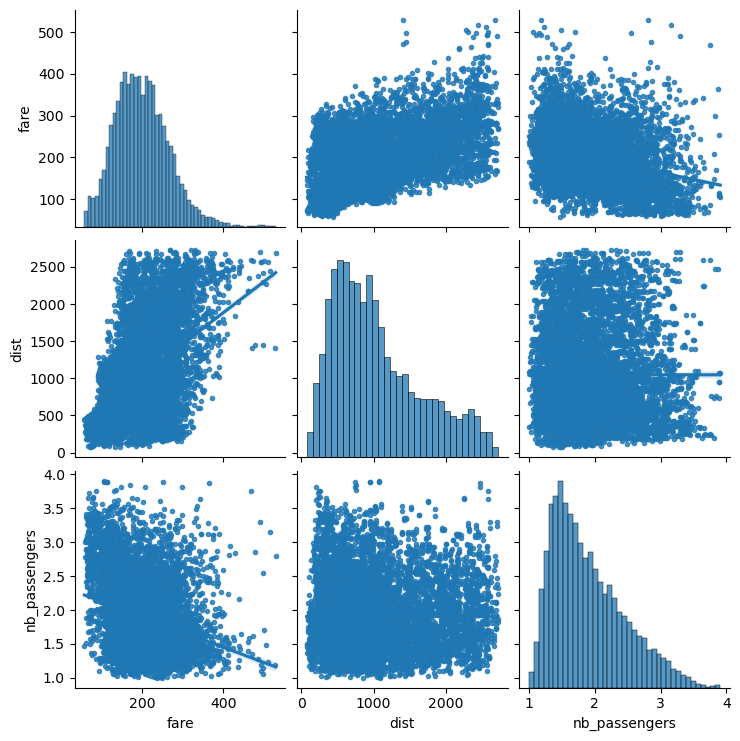

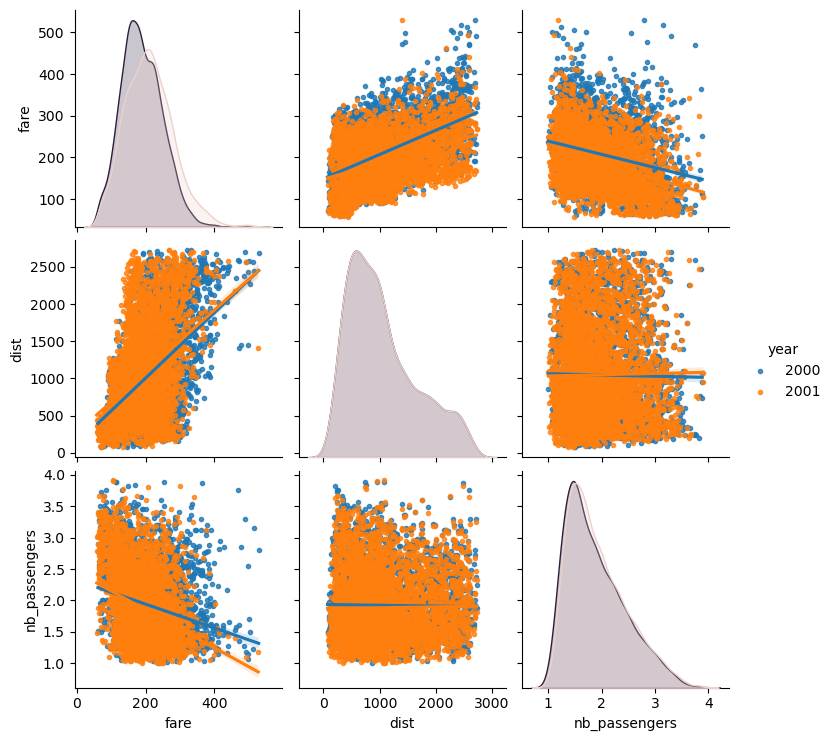

In [51]:
seaborn.pairplot(data_flat, vars=['fare', 'dist', 'nb_passengers'],
                 kind='reg', markers='.')

# A second plot, to show the effect of the year (ie the 9/11 effect)
seaborn.pairplot(data_flat, vars=['fare', 'dist', 'nb_passengers'],
                 kind='reg', hue='year', markers='.');

### Plot the difference in fare

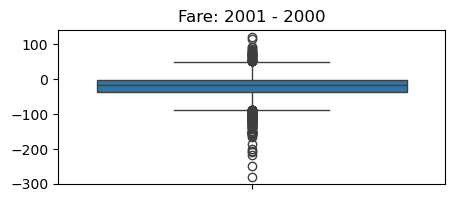

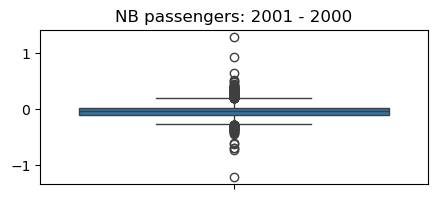

In [52]:
plt.figure(figsize=(5, 2))
seaborn.boxplot(data.fare_2001 - data.fare_2000)
plt.title('Fare: 2001 - 2000')
plt.subplots_adjust()

plt.figure(figsize=(5, 2))
seaborn.boxplot(data.nb_passengers_2001 - data.nb_passengers_2000)
plt.title('NB passengers: 2001 - 2000')
plt.subplots_adjust()

### Statistical testing: dependence of fare on distance and number of passengers

In [53]:
result = sm.ols(formula='fare ~ 1 + dist + nb_passengers', data=data_flat).fit()
print(result.summary())

# Using a robust fit
result = sm.rlm(formula='fare ~ 1 + dist + nb_passengers', data=data_flat).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1585.
Date:                Mon, 27 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:30:51   Log-Likelihood:                -45532.
No. Observations:                8352   AIC:                         9.107e+04
Df Residuals:                    8349   BIC:                         9.109e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       211.2428      2.466     85.669

### Statistical testing: regression of fare on distance: 2001/2000 difference

                            OLS Regression Results                            
Dep. Variable:              fare_2001   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     791.7
Date:                Mon, 27 Jul 2026   Prob (F-statistic):          1.20e-159
Time:                        14:30:51   Log-Likelihood:                -22640.
No. Observations:                4176   AIC:                         4.528e+04
Df Residuals:                    4174   BIC:                         4.530e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    148.0279      1.673     88.480      0.0

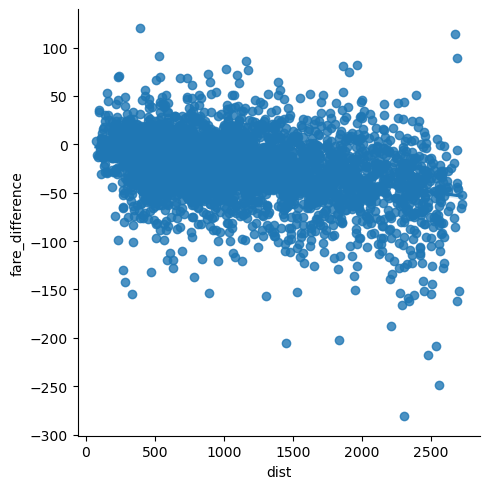

In [54]:
result = sm.ols(formula='fare_2001 - fare_2000 ~ 1 + dist', data=data).fit()
print(result.summary())

# Plot the corresponding regression
data['fare_difference'] = data['fare_2001'] - data['fare_2000']
seaborn.lmplot(x='dist', y='fare_difference', data=data)

plt.show();

## Relating Gender and IQ

#### reading file

In [55]:
data = pd.read_csv('brain_size.csv', sep=';', na_values='.')
model = ols('VIQ ~ Gender + MRI_Count + Height', data).fit()
print(model.summary())
# Here, we don't need to define a contrast, as we are testing a single
# coefficient of our model, and not a combination of coefficients.
# However, defining a contrast, which would then be a 'unit contrast',
# will give us the same results
print(model.f_test([0, 1, 0, 0]));

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     3.809
Date:                Mon, 27 Jul 2026   Prob (F-statistic):             0.0184
Time:                        14:30:51   Log-Likelihood:                -172.34
No. Observations:                  39   AIC:                             352.7
Df Residuals:                      35   BIC:                             359.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        166.6258     88.824      1.

#### plot a scatter matrix

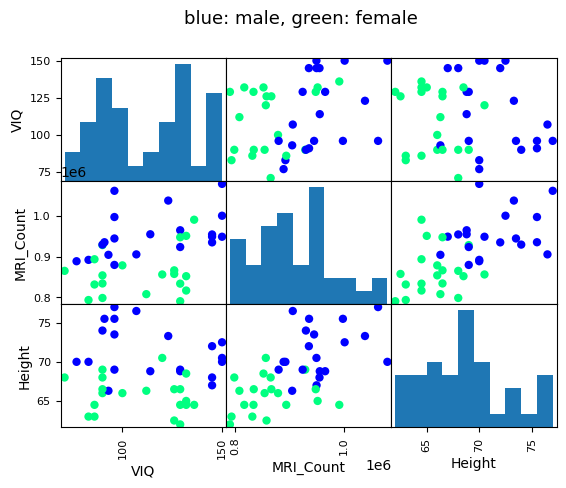

In [56]:
data['Height']= data['Height'].ffill()
plotting.scatter_matrix(data[['VIQ', 'MRI_Count', 'Height']],
                        c=(data['Gender'] == 'Female'), marker='o',
                        alpha=1, cmap='winter')

fig = plt.gcf()
fig.suptitle("blue: male, green: female", size=13)

plt.show();